# CSV Data Exploration

This notebook loads two CSV files and performs basic exploratory analysis and visualization.

## Setup

Import common data analysis and visualization libraries.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")

## Load CSV files

Update the folder path if your CSV files are stored elsewhere.

In [60]:
data_dir = Path(r".\20260205-1")
src_candidates = sorted(data_dir.glob("*_srcE_t_matrix.csv"))
det_candidates = sorted(data_dir.glob("*_detE_t_matrix.csv"))

if not src_candidates or not det_candidates:
    raise FileNotFoundError(
        f"Missing *_srcE_t_matrix.csv or *_detE_t_matrix.csv in {data_dir.resolve()}"
    )

src_path = src_candidates[0]
det_path = det_candidates[0]

src_path, det_path

(WindowsPath('20260205-1/tgf_srcE_t_matrix.csv'),
 WindowsPath('20260205-1/tgf_detE_t_matrix.csv'))

## Quick overview

Load the matrix CSVs and print basic ranges.

In [61]:
def load_matrix_csv(path: Path):
    df = pd.read_csv(path)
    if df.shape[1] < 2:
        raise ValueError(f"Matrix CSV has <2 columns: {path}")
    time_ns = df.iloc[:, 0].to_numpy(dtype=float)
    energy_mev = np.array([float(c) for c in df.columns[1:]], dtype=float)
    counts = df.iloc[:, 1:].to_numpy(dtype=float)
    return time_ns, energy_mev, counts

matrices = {}
for label, path in {"srcE_t": src_path, "detE_t": det_path}.items():
    time_ns, energy_mev, counts = load_matrix_csv(path)
    matrices[label] = (time_ns, energy_mev, counts)
    print(
        f"{label}: shape={counts.shape}, "
        f"time(ns)=[{time_ns.min():.3g}, {time_ns.max():.3g}], "
        f"E(MeV)=[{energy_mev.min():.3g}, {energy_mev.max():.3g}]"
    )


srcE_t: shape=(1000, 2000), time(ns)=[5, 1e+04], E(MeV)=[0.0025, 10]
detE_t: shape=(1000, 2000), time(ns)=[5, 1e+04], E(MeV)=[0.0025, 10]


## Time-resolved spectra plots

Plot the time-energy matrix and basic projections.

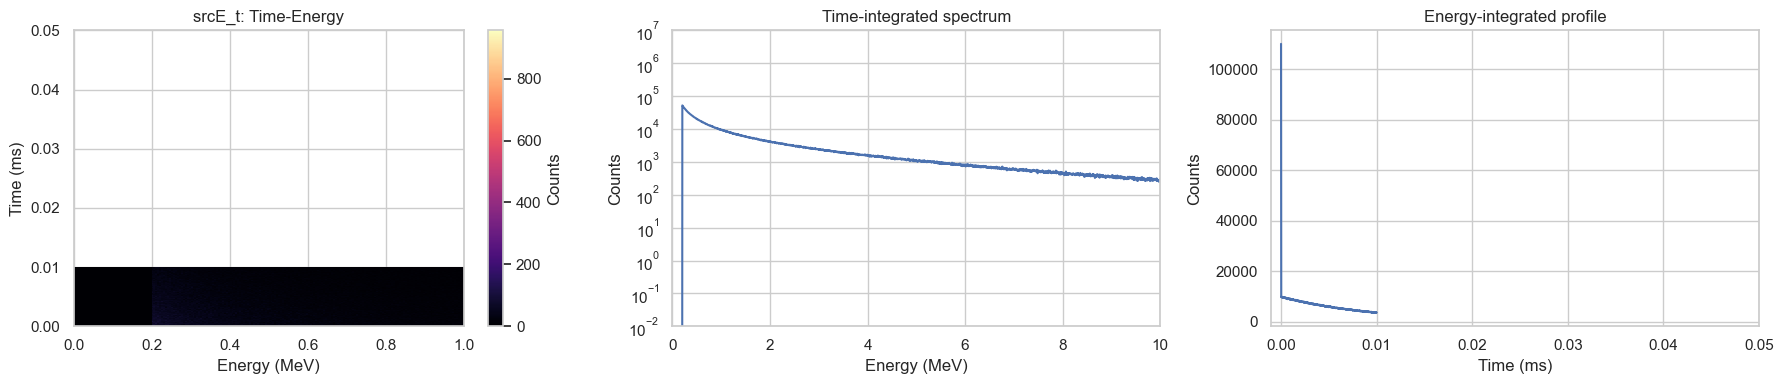

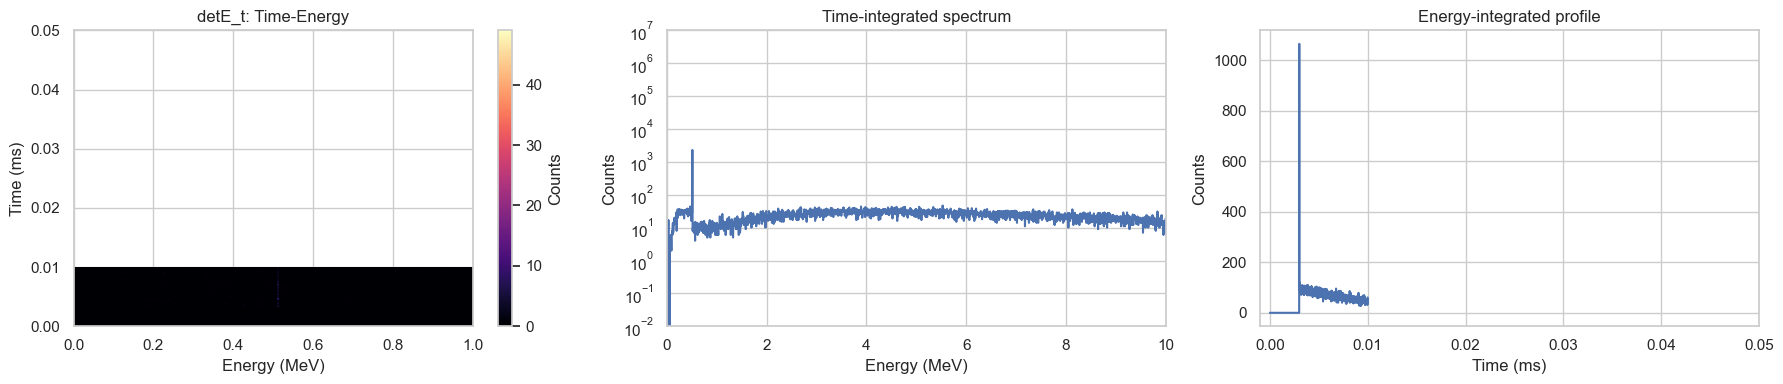

In [62]:
def plot_matrix(label, time_ns, energy_mev, counts):
    time_ms = time_ns * 1e-6

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    mesh = axes[0].pcolormesh(energy_mev, time_ms, counts, shading="auto", cmap="magma")
    axes[0].set_title(f"{label}: Time-Energy")
    axes[0].set_xlabel("Energy (MeV)")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 0.05)
    axes[0].set_ylabel("Time (ms)")
    fig.colorbar(mesh, ax=axes[0], label="Counts")

    energy_spectrum = counts.sum(axis=0)
    axes[1].semilogy(energy_mev, energy_spectrum + 1e-12)
    axes[1].set_title("Time-integrated spectrum")
    axes[1].set_xlabel("Energy (MeV)")
    axes[1].set_ylim(1e-2, 10**7)
    axes[1].set_xlim(0, 10)
    axes[1].set_ylabel("Counts")

    time_profile = counts.sum(axis=1)
    axes[2].plot(time_ms, time_profile)
    axes[2].set_title("Energy-integrated profile")
    axes[2].set_xlabel("Time (ms)")
    axes[2].set_xlim(-0.001, 0.05)
    axes[2].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

for label, (time_ns, energy_mev, counts) in matrices.items():
    plot_matrix(label, time_ns, energy_mev, counts)

## Comparison plots

Overlay source vs detector projections (normalized).

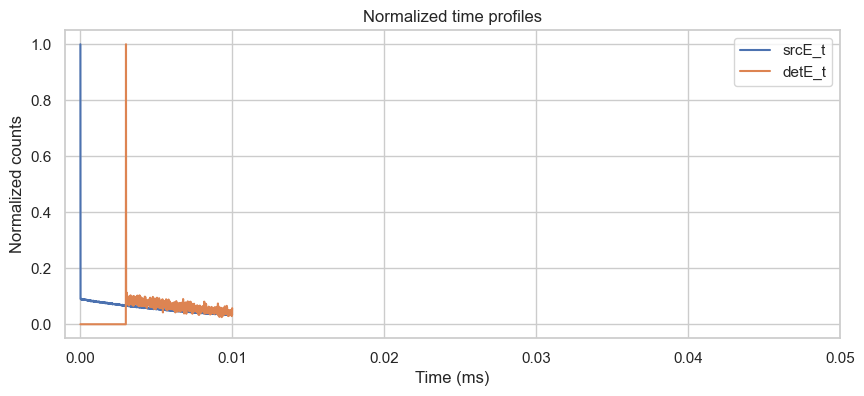

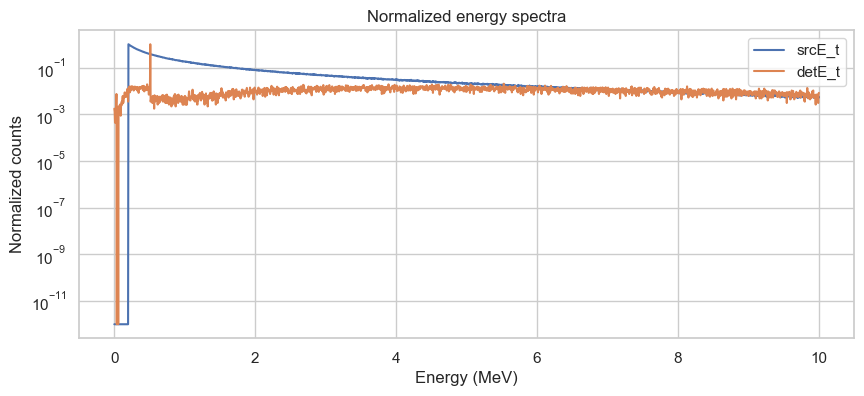

In [63]:
plt.figure(figsize=(10, 4))
for label, (time_ns, energy_mev, counts) in matrices.items():
    time_ms = time_ns * 1e-6
    profile = counts.sum(axis=1)
    if profile.max() > 0:
        profile = profile / profile.max()
    plt.plot(time_ms, profile, label=label)
plt.title("Normalized time profiles")
plt.xlabel("Time (ms)")
plt.ylabel("Normalized counts")
plt.xlim(-0.001, 0.05)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for label, (time_ns, energy_mev, counts) in matrices.items():
    spectrum = counts.sum(axis=0)
    if spectrum.max() > 0:
        spectrum = spectrum / spectrum.max()
    plt.semilogy(energy_mev, spectrum + 1e-12, label=label)
plt.title("Normalized energy spectra")
plt.xlabel("Energy (MeV)")
plt.ylabel("Normalized counts")
plt.legend()
plt.show()

## Animated spectrum over time

Each frame shows the energy spectrum at one time bin, scanned through the full time range.

In [64]:
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

selected_label = "detE_t" if "detE_t" in matrices else list(matrices.keys())[0]
time_ns, energy_mev, counts = matrices[selected_label]
time_ms = time_ns * 1e-6

# Increase embed limit (MB) to avoid dropped frames in notebook output.
mpl.rcParams["animation.embed_limit"] = 80

# Increase frame_step to reduce animation size if needed.
frame_step = 10
max_frames = 300

frame_indices = np.arange(0, len(time_ms), frame_step, dtype=int)
if len(frame_indices) > max_frames:
    frame_indices = np.linspace(0, len(frame_indices) - 1, max_frames, dtype=int)
    frame_indices = np.unique(frame_indices)
    frame_indices = np.array([int(np.arange(0, len(time_ms), frame_step)[i]) for i in frame_indices], dtype=int)

fig, ax = plt.subplots(figsize=(9, 5), dpi=90)
line, = ax.plot([], [], lw=1.5)
ax.set_title(f"{selected_label} - Dynamic energy spectrum")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Counts")
ax.set_yscale("log")
ax.set_xlim(float(energy_mev.min()), float(energy_mev.max()))
ymax = float(np.nanmax(counts)) if np.size(counts) else 1.0
ax.set_ylim(1e-12, max(1e-11, ymax * 1.1))
time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")

def init():
    line.set_data([], [])
    time_text.set_text("")
    return line, time_text

def update(frame_idx):
    spectrum = np.maximum(counts[frame_idx, :], 1e-12)
    line.set_data(energy_mev, spectrum)
    time_text.set_text(f"t = {time_ms[frame_idx]:.6f} ms (index {frame_idx})")
    return line, time_text

ani = FuncAnimation(fig, update, frames=frame_indices, init_func=init, interval=40, blit=True, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml(fps=20))


## Additional spectra: deposited energy and process components

Visualize `tgf_depE_t_matrix.csv` and `tgf_detE_by_process.csv` in Energy-Counts style.

dep file: 20260205-1\tgf_depE_t_matrix.csv
by-process file: 20260205-1\tgf_detE_by_process.csv


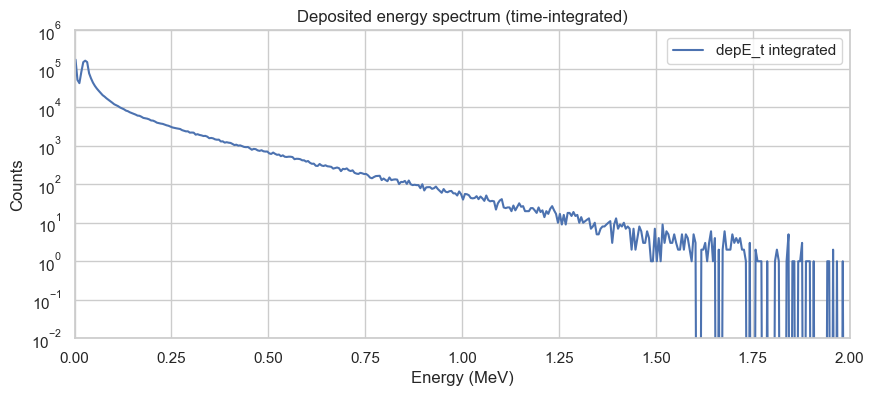

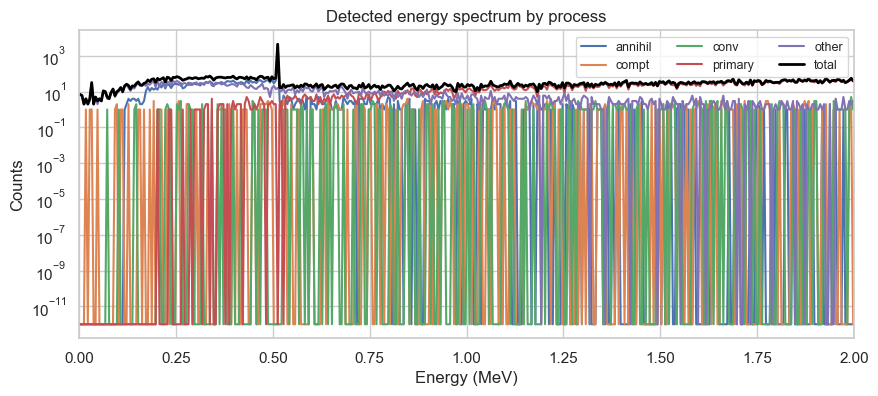

In [65]:
dep_candidates = sorted(data_dir.glob("*_depE_t_matrix.csv"))
proc_candidates = sorted(data_dir.glob("*_detE_by_process.csv"))

if not dep_candidates:
    raise FileNotFoundError(f"Missing *_depE_t_matrix.csv in {data_dir.resolve()}")
if not proc_candidates:
    raise FileNotFoundError(f"Missing *_detE_by_process.csv in {data_dir.resolve()}")

dep_path = dep_candidates[0]
proc_path = proc_candidates[0]
print(f"dep file: {dep_path}")
print(f"by-process file: {proc_path}")

# 1) Deposited-energy matrix -> time-integrated energy spectrum
dep_time_ns, dep_energy_mev, dep_counts = load_matrix_csv(dep_path)
dep_spectrum = dep_counts.sum(axis=0)

plt.figure(figsize=(10, 4))
plt.semilogy(dep_energy_mev, dep_spectrum + 1e-12, label="depE_t integrated")
plt.title("Deposited energy spectrum (time-integrated)")
plt.xlabel("Energy (MeV)")
plt.ylabel("Counts")
plt.xlim(0, 2)
plt.ylim(1e-2, 1e6)
plt.legend()
plt.show()

# 2) Detected spectrum by process
proc_df = pd.read_csv(proc_path)
energy_col = proc_df.columns[0]
energy_mev = proc_df[energy_col].to_numpy(dtype=float)

process_cols = [c for c in proc_df.columns[1:] if c.lower() != "total"]
has_total = any(c.lower() == "total" for c in proc_df.columns[1:])

plt.figure(figsize=(10, 4))
for col in process_cols:
    y = proc_df[col].to_numpy(dtype=float)
    plt.semilogy(energy_mev, y + 1e-12, label=col)

if has_total:
    total_col = [c for c in proc_df.columns[1:] if c.lower() == "total"][0]
    y_total = proc_df[total_col].to_numpy(dtype=float)
    plt.semilogy(energy_mev, y_total + 1e-12, color="black", linewidth=2, label=total_col)

plt.title("Detected energy spectrum by process")
plt.xlabel("Energy (MeV)")
plt.ylabel("Counts")
plt.xlim(0, 2)
plt.legend(ncol=3, fontsize=9)
plt.show()


## By-process spectra in separate plots

Plot each process from `tgf_detE_by_process.csv` in an individual figure.

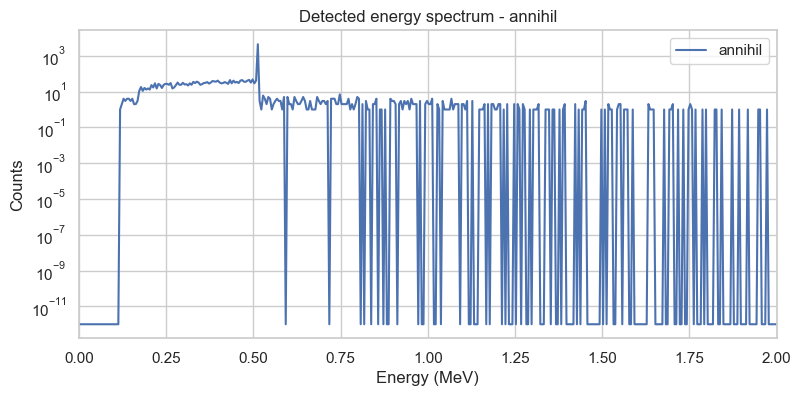

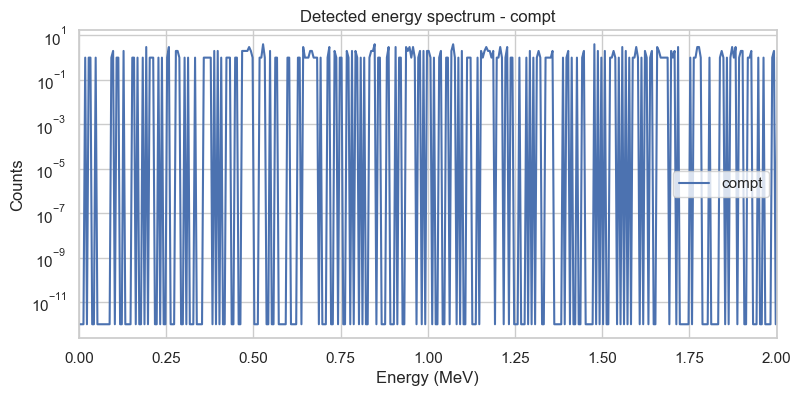

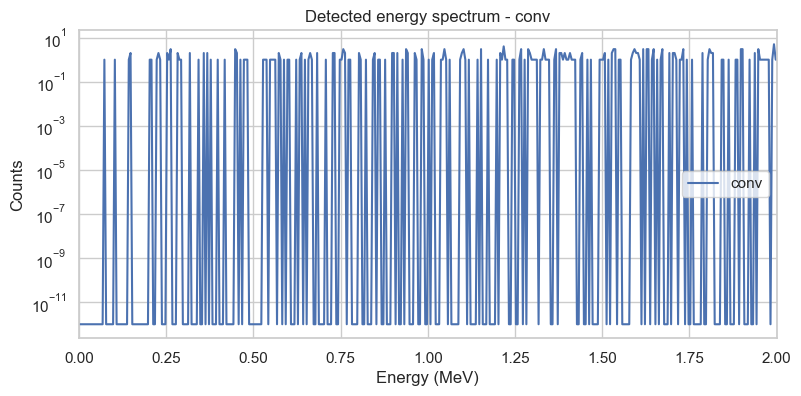

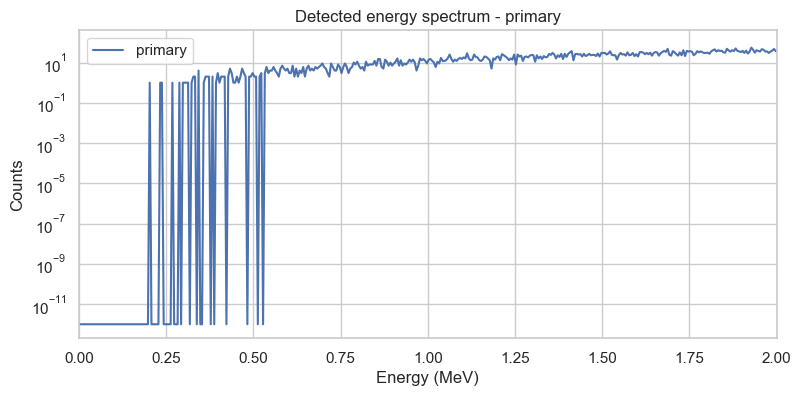

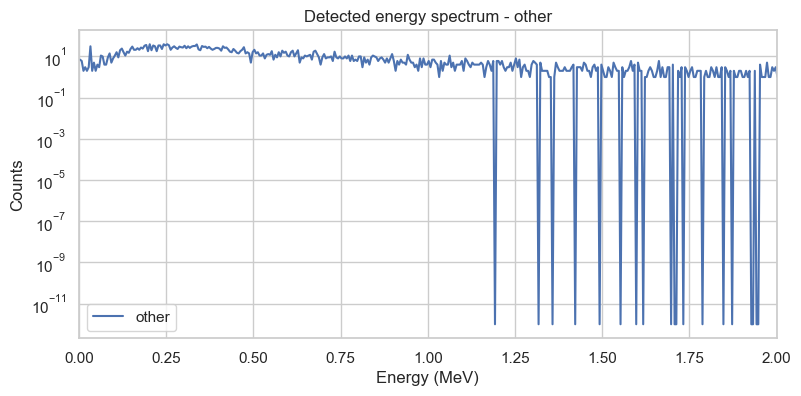

In [66]:
proc_candidates = sorted(data_dir.glob("*_detE_by_process.csv"))
if not proc_candidates:
    raise FileNotFoundError(f"Missing *_detE_by_process.csv in {data_dir.resolve()}")

proc_df = pd.read_csv(proc_candidates[0])
energy_col = proc_df.columns[0]
energy_mev = proc_df[energy_col].to_numpy(dtype=float)
process_cols = [c for c in proc_df.columns[1:] if c.lower() != "total"]

for col in process_cols:
    y = proc_df[col].to_numpy(dtype=float)
    plt.figure(figsize=(9, 4))
    plt.semilogy(energy_mev, y + 1e-12, label=col)
    plt.title(f"Detected energy spectrum - {col}")
    plt.xlabel("Energy (MeV)")
    plt.ylabel("Counts")
    plt.xlim(0, 2)
    plt.legend()
    plt.show()
